In [272]:
import numpy as np
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from models import f_lin, f_quad
from sampler import HBM_log_likelihood, t_like_df1, t_like_df5, gauss_like

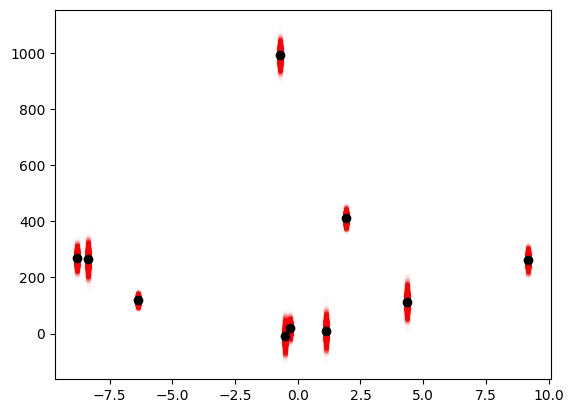

In [273]:
xx = np.linspace(-10, 10, 100)
x = xx[np.random.randint(100, size=10)]

true_a = 20
true_b = -2
true_c = 3

sig = 20
true_y = true_a + x * true_b + x * x * true_c + np.random.standard_cauchy(len(x)) * sig

sig0 = 6
sigs = np.random.rand(len(true_y)) * sig + sig0

nsamps = 10000
y_samples = jnp.array([yi + np.random.randn(nsamps) * s for yi, s in zip(true_y, sigs)])

[plt.plot(xi * np.ones(nsamps), yi, 'r.', alpha=0.01) for xi, yi in zip(x, y_samples)];
plt.plot(x, true_y, 'ko')

In [274]:
import emcee

initial = [20, 2, 3, 0.5]
pos = initial + 1e-4 * np.random.randn(32, len(initial))
nwalkers, ndim = pos.shape

ll = jax.jit(lambda p: HBM_log_likelihood(x, p[:-1], p[-1:], y_samples, f_quad, t_like_df1))
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, ll
)
sampler.run_mcmc(pos, 10000, progress=True);

100%|████████████████████████████████████| 10000/10000 [00:38<00:00, 258.32it/s]


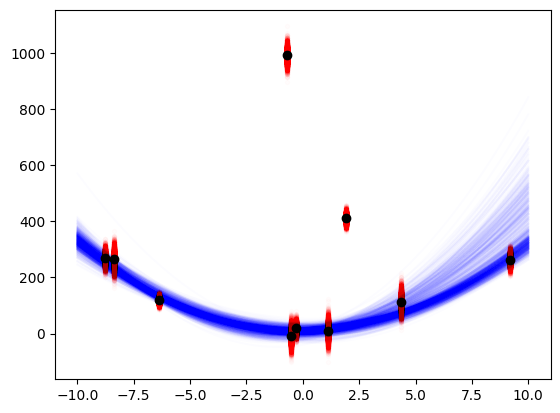

In [282]:
flat_samples = sampler.flatchain
inds = np.random.randint(len(flat_samples), size=1000)
models = np.array([f_quad(xx, flat_samples[i][:-1]) for i in inds])

plt.plot(xx, models.T, color='b', alpha=0.01);
[plt.plot(xi * np.ones(nsamps), yi, 'r.', alpha=0.01) for xi, yi in zip(x, y_samples)];
plt.plot(x, true_y, 'ko')